In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [86]:
pd.options.display.float_format = '{:20.2f}'.format
# to display the decimal to 2 digits only

In [29]:
pd.set_option('display.max_columns',999)

In [30]:
df = pd.read_excel('C:/Users/Aditya SC/Downloads/TEMP DATA/online_retail_II.xlsx', sheet_name=0)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [32]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [33]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [34]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [35]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [36]:
df[df['Customer ID'].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [37]:
df[df['Quantity']<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [38]:
df['Invoice'] = df['Invoice'].astype("str")
df[df['Invoice'].str.match("^\\d{6}$")== False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


In [39]:
df['Invoice'].str.replace("[0-9]","",regex= True).unique()

array(['', 'C', 'A'], dtype=object)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [41]:
df[df['Invoice'].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [42]:
df['StockCode'] = df['StockCode'].astype("str")
df[(df['StockCode'].str.match("^\\d{5}$")== False) & (df['StockCode'].str.match("^\\d{5}[A-Z]$")== False)]['StockCode'].unique()

array(['POST', '79323LP', '15056BL', 'D', '79323GR', 'DCGS0058',
       'DCGS0068', 'DOT', '72349b', '72529w', '72807c', '84797b',
       '84872a', '84873a', '85114b', '18096c', '84797a', '85014b',
       '85132a', '18098c', '48173c', '79070b', '84030c', '84558a',
       '47518f', '15056bl', '35004c', '84796b', '85040a', '85164b', 'M',
       '84705b', '35004s', '84509c', '84951b', '37482p', '85114c',
       'DCGS0004', 'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003',
       'TEST001', 'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044',
       'TEST002', 'gift_0001_10', 'gift_0001_50', '37494a', '84406b',
       '72807b', '85232b', '85159b', 'DCGS0066N', '47567b', '85124b',
       '85184c', '79051a', '85114a', '37482b', '79302m', '84509a',
       '84912a', '85123b', '84029c', 'gift_0001_30', 'PADS', '72024HC',
       '84030b', '84596e', '72801d', '84993b', '84989b', '84993a',
       '84867b', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', '84559a', '8

In [43]:
df[df['StockCode'].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


## DATA CLEANING

In [44]:
cleaned_df = df.copy()

In [45]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype("str")

mask =(
    cleaned_df['Invoice'].str.match("^\\d{6}$") == True
)  
cleaned_df = cleaned_df[mask] 
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [46]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype("str")
mask =(
    (cleaned_df['StockCode'].str.match("^\\d{5}$") == True)
    | (cleaned_df['StockCode'].str.match("^\\d{5}$[a-zA-Z+$]") == True)
    | (cleaned_df['StockCode'].str.match("^PADS$]") == True)
)
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [47]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,515252.00,515252,515252.00,407695.00
mean,10.96,2010-06-28 17:40:54.093763584,4.22,15368.50
min,-9600.00,2009-12-01 07:45:00,0.00,12346.00
25%,1.00,2010-03-21 13:27:00,1.25,13997.00
50%,3.00,2010-07-06 13:13:00,2.10,15321.00
75%,10.00,2010-10-15 14:27:00,4.21,16812.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,104.35,NaN,63.44,1679.80


In [48]:
cleaned_df.dropna(subset= ['Customer ID'],inplace = True)
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [49]:
df = pd.read_excel("C:\\Users\\Aditya SC\\Downloads\\TEMP DATA\\online_retail_II.xlsx", sheet_name=0)

In [50]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,407695.00,407695,407695.00,407695.00
mean,13.59,2010-07-01 10:10:10.782177792,3.29,15368.50
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,13997.00
50%,5.00,2010-07-09 15:46:00,1.95,15321.00
75%,12.00,2010-10-14 17:09:00,3.75,16812.00
max,19152.00,2010-12-09 20:01:00,10953.50,18287.00
std,96.84,NaN,34.76,1679.80


In [51]:
len(cleaned_df[cleaned_df['Price'] == 0])

31

In [53]:
cleaned_df= cleaned_df[cleaned_df['Price']> 0]

In [54]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,407664.00,407664,407664.00,407664.00
mean,13.59,2010-07-01 10:15:11.871688192,3.29,15368.59
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,13997.00
50%,5.00,2010-07-09 15:47:00,1.95,15321.00
75%,12.00,2010-10-14 17:09:00,3.75,16812.00
max,19152.00,2010-12-09 20:01:00,10953.50,18287.00
std,96.84,NaN,34.76,1679.76


In [55]:
(len(cleaned_df)/len(df) )*100

#the percentage of data retained after cleaning

77.5821611879854

## Feature Enginerring

In [56]:
cleaned_df['SalesLineTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


In [57]:
cleaned_df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'SalesLineTotal'],
      dtype='object')

In [58]:
aggregated_df = cleaned_df.groupby(by = 'Customer ID', as_index = False) \
    .agg(
        MonetaryValue = ('SalesLineTotal','sum'),
        Frequency = ('Invoice','nunique'),
        LastInvoiceDate = ('InvoiceDate','max')
    )
aggregated_df.head(10)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,372.86,11,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,222.16,1,2010-09-27 14:59:00
3,12349.00,2671.14,3,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00
5,12352.00,343.80,2,2010-11-29 10:07:00
6,12353.00,317.76,1,2010-10-27 12:44:00
7,12355.00,488.21,1,2010-05-21 11:59:00
8,12356.00,3562.25,3,2010-11-24 12:24:00
9,12357.00,12079.99,2,2010-11-16 14:29:00


In [59]:
MaxInvoiceDate = aggregated_df['LastInvoiceDate'].max()

aggregated_df['Recency'] = (MaxInvoiceDate - aggregated_df['LastInvoiceDate']).dt.days
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,372.86,11,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,222.16,1,2010-09-27 14:59:00,73
3,12349.00,2671.14,3,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


## TO_GET_IDEA & RID_OF_OUTLIERS

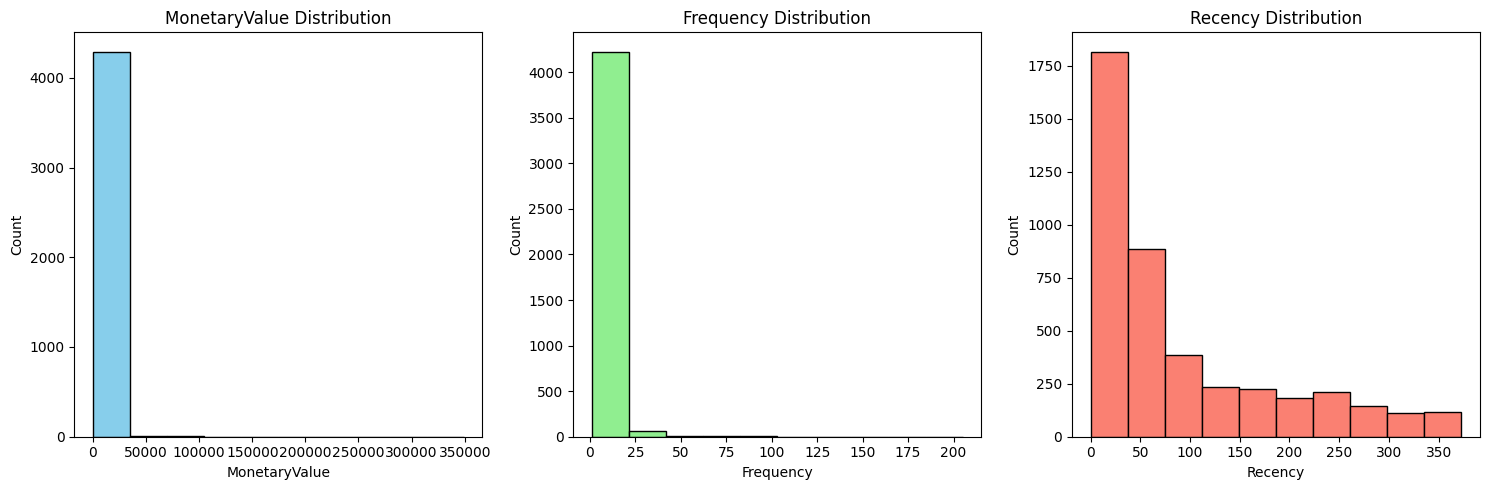

In [60]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(aggregated_df['MonetaryValue'],bins = 10, color = 'skyblue',edgecolor= 'black' )
plt.title('MonetaryValue Distribution')
plt.xlabel('MonetaryValue')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(aggregated_df['Frequency'],bins = 10, color = 'lightgreen',edgecolor= 'black' )
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist(aggregated_df['Recency'],bins = 10, color = 'salmon',edgecolor= 'black' )
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

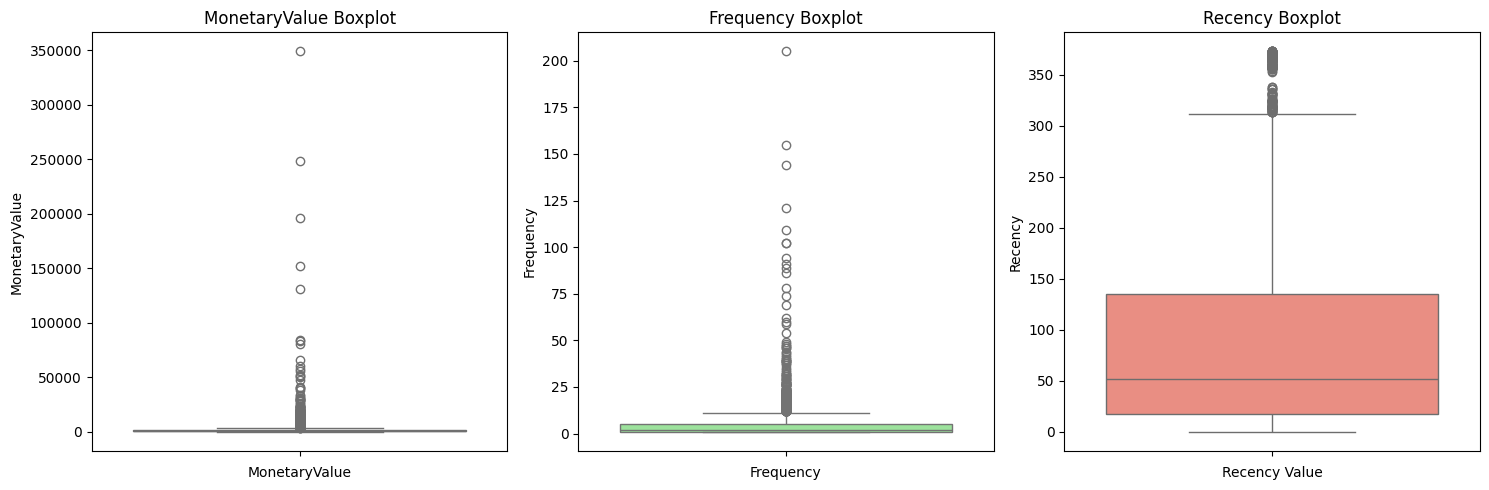

In [61]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(aggregated_df['MonetaryValue'],color = 'skyblue')
plt.title('MonetaryValue Boxplot')
plt.xlabel('MonetaryValue')

plt.subplot(1,3,2)
sns.boxplot(aggregated_df['Frequency'],color = 'lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1,3,3)
sns.boxplot(aggregated_df['Recency'],color = 'salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency Value')

plt.tight_layout()
plt.show()

In [62]:
M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q1

np.float64(307.9875)

In [63]:
M_Q3 = aggregated_df['MonetaryValue'].quantile(0.75)
M_Q3

np.float64(1723.1425)

In [64]:
M_IQR = M_Q3-M_Q1

MonetaryValuesOutliers_df = aggregated_df[(aggregated_df['MonetaryValue'] > (M_Q3 + 1.5 * M_IQR))|
    (aggregated_df['MonetaryValue'] < (M_Q1 - 1.5 * M_IQR))].copy()

MonetaryValuesOutliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,428.00,428.00,428.00,428,428.00
mean,15060.06,12319.51,17.28,2010-11-09 16:05:02.943925248,29.88
min,12357.00,3851.01,1.00,2010-01-17 11:33:00,0.00
25%,13573.00,4610.06,8.00,2010-11-08 10:35:30,3.00
50%,14927.00,6262.58,12.00,2010-11-26 11:15:30,13.00
75%,16653.00,10409.57,18.00,2010-12-06 09:54:45,31.00
max,18260.00,349164.35,205.00,2010-12-09 19:32:00,326.00
std,1729.85,26044.46,20.49,NaN,49.23


In [65]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)

F_IQR = F_Q3-F_Q1

FrequencyOutliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR))|
    (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

FrequencyOutliers_df .describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,285.00,285.00,285.00,285,285.00
mean,15307.80,14374.58,23.91,2010-11-23 13:55:24.631578880,15.97
min,12422.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13715.00,4331.41,13.00,2010-11-19 15:51:00,2.00
50%,15311.00,6507.67,17.00,2010-12-02 08:52:00,7.00
75%,16814.00,11645.70,23.00,2010-12-07 10:08:00,20.00
max,18260.00,349164.35,205.00,2010-12-09 19:32:00,211.00
std,1773.26,31518.80,22.83,NaN,25.78


In [66]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(MonetaryValuesOutliers_df.index)) & 
    (~aggregated_df.index.isin(FrequencyOutliers_df.index))]

non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3828.00,3828.00,3828.00,3828,3828.00
mean,15372.74,889.86,2.86,2010-09-02 15:28:27.931034368,97.91
min,12346.00,2.95,1.00,2009-12-01 09:55:00,0.00
25%,13910.50,281.21,1.00,2010-07-07 12:00:45,22.00
50%,15380.50,589.13,2.00,2010-10-12 12:44:30,58.00
75%,16846.25,1273.61,4.00,2010-11-17 13:09:30,155.00
max,18287.00,3817.18,11.00,2010-12-09 20:01:00,373.00
std,1693.30,824.81,2.24,NaN,98.74


  ## VALIDATING_REMOVAL_OF_OUTLIERS

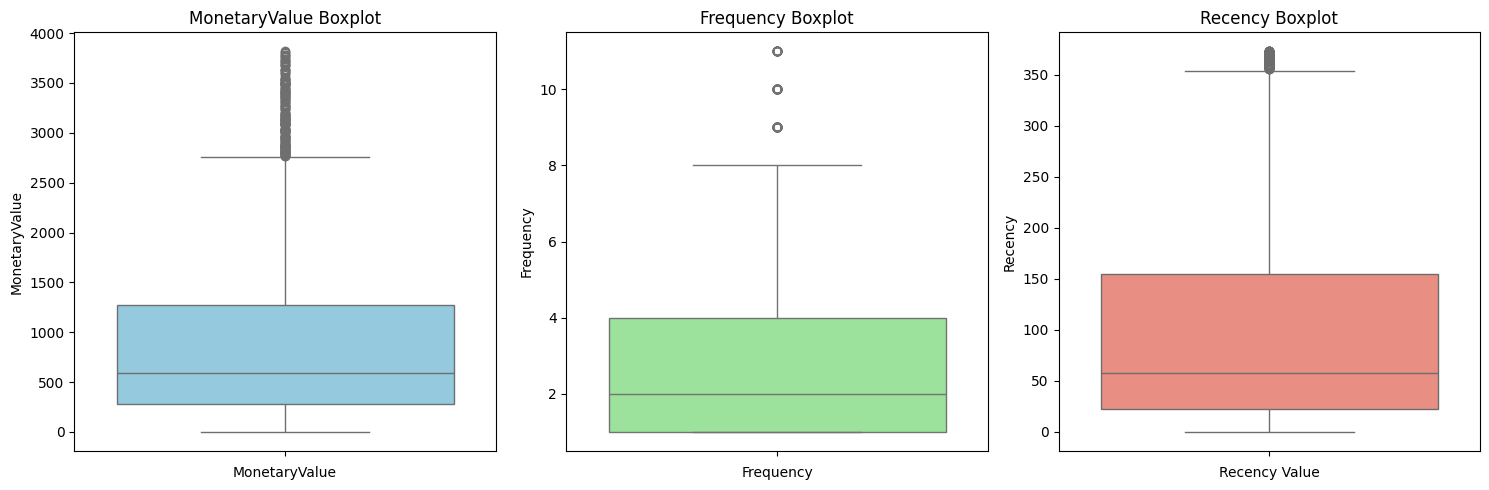

In [67]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(data = non_outliers_df['MonetaryValue'],color = 'skyblue')
plt.title('MonetaryValue Boxplot')
plt.xlabel('MonetaryValue')

plt.subplot(1,3,2)
sns.boxplot(data = non_outliers_df['Frequency'],color = 'lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1,3,3)
sns.boxplot(data = non_outliers_df['Recency'],color = 'salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency Value')

plt.tight_layout()
plt.show()

Text(0.5, 0.92, '3D SCATTERPLOT OF CUSTOMER DATA')

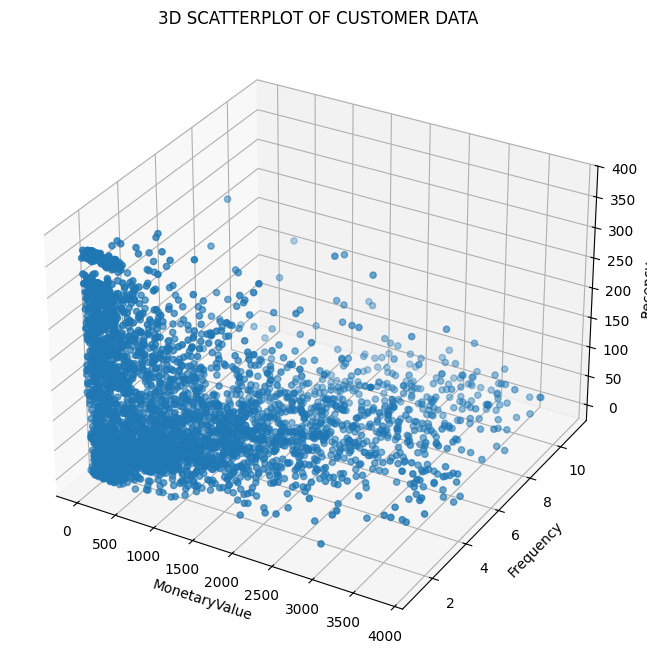

In [68]:
fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],non_outliers_df['Frequency'],non_outliers_df['Recency'])

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D SCATTERPLOT OF CUSTOMER DATA')

## STANDARD SCALLING TRANSFORMATION

In [69]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue','Frequency','Recency']])

scaled_data

array([[-0.62689958,  3.62975807,  0.66943051],
       [ 0.52559219, -0.38566835, -0.9714245 ],
       [-0.80963268, -0.83182684, -0.25228434],
       ...,
       [-0.56125147, -0.83182684,  1.99629474],
       [ 0.49298639, -0.38566835,  0.13260757],
       [ 1.76530355,  0.50664863, -0.81949348]])

In [70]:
 scaled_data_df = pd.DataFrame(scaled_data, index = non_outliers_df.index, columns =('MonetaryValue','Frequency','Recency'))

scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.63,3.63,0.67
1,0.53,-0.39,-0.97
2,-0.81,-0.83,-0.25
3,2.16,0.06,-0.57
4,-0.71,-0.83,-0.89
...,...,...,...
4307,-0.30,1.40,-0.82
4308,-0.52,-0.83,-0.32
4309,-0.56,-0.83,2.00
4310,0.49,-0.39,0.13


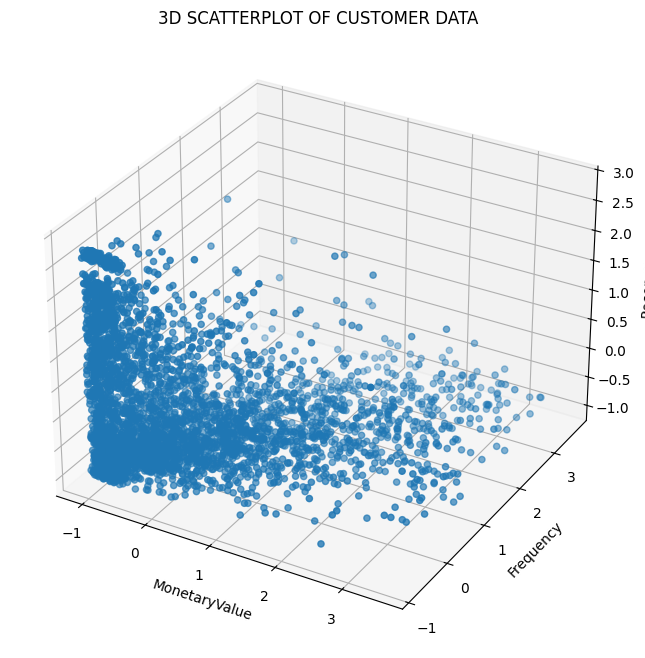

In [71]:
fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(scaled_data_df['MonetaryValue'],scaled_data_df['Frequency'],scaled_data_df['Recency'])

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D SCATTERPLOT OF CUSTOMER DATA')
plt.show()

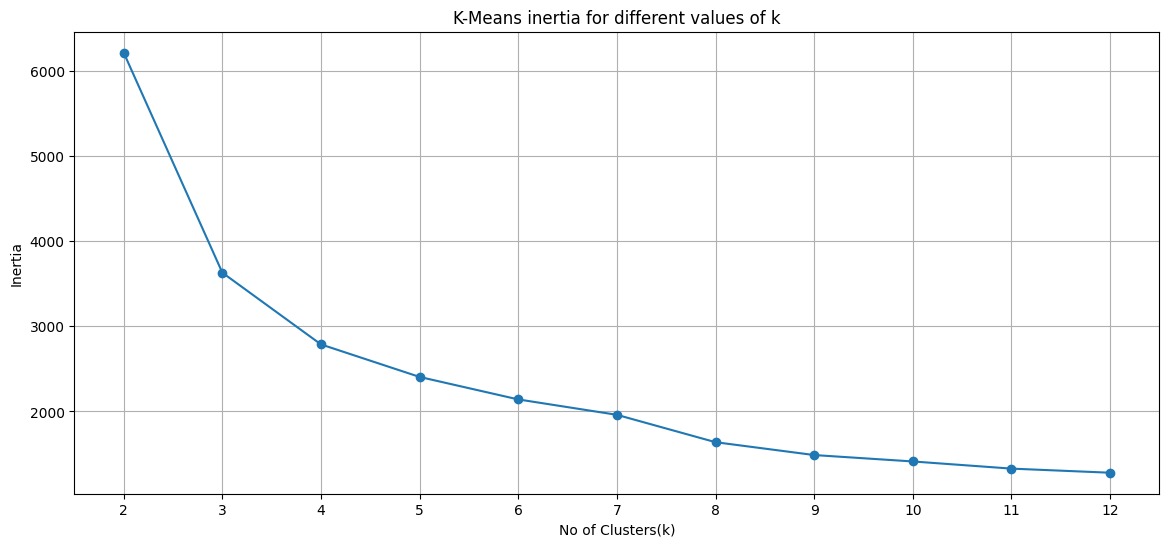

In [72]:
max_k = 12

inertia = []

k_values = range(2,max_k + 1)
for k in k_values:
    kmeans = KMeans(n_clusters = k,random_state = 42 , max_iter = 1000)

    kmeans.fit_predict(scaled_data_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize = (14,6))
plt.plot(k_values,inertia,marker = 'o')
plt.title('K-Means inertia for different values of k')
plt.xlabel('No of Clusters(k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

max_k = 12

inertia = []

silhoutte_scores = []

k_values = range(2,max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters = k,random_state = 42 , max_iter = 1000)

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    silhoutte_scores.append(sil_score)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize = (14,6))

plt.subplot(1, 2, 1)
plt.plot(k_values,inertia,marker ='o')
plt.title('K-Means inertia for different values of k')
plt.xlabel('No of Clusters(k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values,silhoutte_scores,marker ='o',color = 'orange')
plt.title('Silhouette Score of different values of k')
plt.xlabel('No of Clusters(k)')
plt.ylabel('Silhoutte Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()


In [73]:
kmeans = KMeans(n_clusters = 4,random_state = 42, max_iter = 1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

cluster_labels

array([3, 2, 1, ..., 0, 2, 2], dtype=int32)

In [74]:
non_outliers_df['Cluster'] = cluster_labels

non_outliers_df

C:\Users\Aditya SC\AppData\Local\Temp\ipykernel_14800\1791966522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster'] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,372.86,11,2010-06-28 13:53:00,164,3
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,2
2,12348.00,222.16,1,2010-09-27 14:59:00,73,1
3,12349.00,2671.14,3,2010-10-28 08:23:00,42,2
4,12351.00,300.93,1,2010-11-29 15:23:00,10,1
...,...,...,...,...,...,...
4307,18283.00,641.77,6,2010-11-22 15:30:00,17,2
4308,18284.00,461.68,1,2010-10-04 11:33:00,66,1
4309,18285.00,427.00,1,2010-02-17 10:24:00,295,0
4310,18286.00,1296.43,2,2010-08-20 11:57:00,111,2


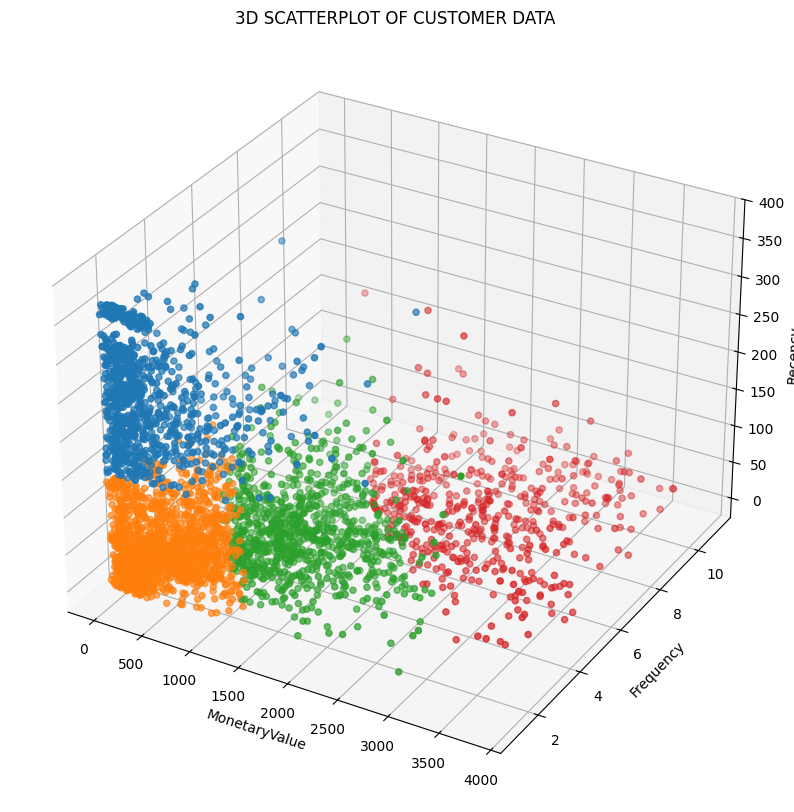

In [75]:
cluster_colors = {0: '#1f77b4', #blue
                  1: '#ff7f0e', #orange
                  2: '#2ca02c', #green
                  3: '#d62728'} #red

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c = colors,
                     marker = 'o')

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D SCATTERPLOT OF CUSTOMER DATA')
plt.show()

Text(0, 0.5, 'Monetary_value')

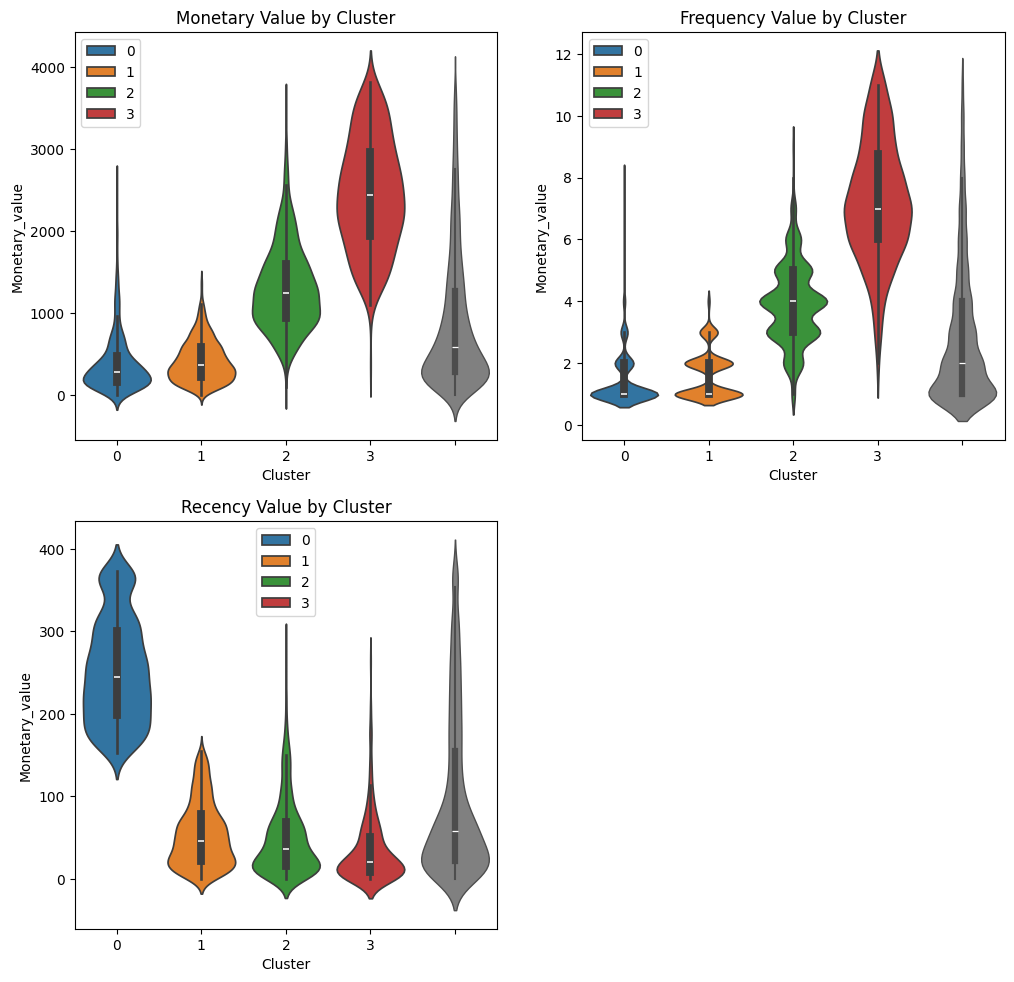

In [76]:
plt.figure(figsize = (12,18))

plt.subplot(3,2,1)
sns.violinplot(x= non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette = cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['MonetaryValue'], color = 'gray',linewidth = 1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary_value')

plt.subplot(3,2,2)
sns.violinplot(x= non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette = cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['Frequency'], color = 'gray',linewidth = 1.0)
plt.title('Frequency Value by Cluster')
plt.ylabel('Monetary_value')

plt.subplot(3,2,3)
sns.violinplot(x= non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette = cluster_colors, hue = non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['Recency'], color = 'gray',linewidth = 1.0)
plt.title('Recency Value by Cluster')
plt.ylabel('Monetary_value')
    

In [77]:
""" 
BLUE_CLUSTER = LOW MONETARY VALUE AND FREQUENCY ,BUT HIGH RECENCY . PROBABLY THEY ARE RECENT CUSTOMERS.

ORANGE_CLUSTER = LOW MONETARY VALUE AND AVERAGE FREQUENCY WITH ABOVE AVERAGE RECENCY

GREEN_CLUSTER = AVERAGE MONETARY VALUE,MORE THAN AVERAGE FREQUENCY AND ARE RECENT BUYERS

RED_CLUSTER = HIHGH MONETARY VALUE AND FREQUENCY WITH LOW RECENCY RATE 
"""

' \nBLUE_CLUSTER = LOW MONETARY VALUE AND FREQUENCY ,BUT HIGH RECENCY . PROBABLY THEY ARE RECENT CUSTOMERS.\n\nORANGE_CLUSTER = LOW MONETARY VALUE AND AVERAGE FREQUENCY WITH ABOVE AVERAGE RECENCY\n\nGREEN_CLUSTER = AVERAGE MONETARY VALUE,MORE THAN AVERAGE FREQUENCY AND ARE RECENT BUYERS\n\nRED_CLUSTER = HIHGH MONETARY VALUE AND FREQUENCY WITH LOW RECENCY RATE \n'

In [78]:
overlap_indices = MonetaryValuesOutliers_df.index.intersection(FrequencyOutliers_df.index)

Monetary_Outliers_only = MonetaryValuesOutliers_df.drop(overlap_indices)
Frequency_Outliers_only = FrequencyOutliers_df.drop(overlap_indices)

Monetary_and_Frequency_outliers = MonetaryValuesOutliers_df.loc[overlap_indices]

Monetary_and_Frequency_outliers['Cluster'] = -1
Monetary_Outliers_only['Cluster'] = -3
Frequency_Outliers_only['Cluster'] = -2

outliers_cluster_df = pd.concat([Monetary_Outliers_only,Monetary_and_Frequency_outliers,Frequency_Outliers_only])

df = outliers_cluster_df[outliers_cluster_df['Cluster'] == -1]
df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
56,12422.00,4428.24,14,2010-11-10 13:19:00,29,-1
63,12431.00,4370.52,13,2010-12-01 10:03:00,8,-1
67,12437.00,7731.99,21,2010-11-09 14:46:00,30,-1
87,12471.00,20139.74,49,2010-11-30 14:35:00,9,-1
88,12472.00,11308.48,13,2010-12-05 14:19:00,4,-1
...,...,...,...,...,...,...
4262,18223.00,7516.31,12,2010-11-17 12:20:00,22,-1
4263,18225.00,7545.14,15,2010-12-09 15:46:00,0,-1
4264,18226.00,6650.83,15,2010-11-26 15:51:00,13,-1
4268,18231.00,4797.70,23,2010-10-29 14:17:00,41,-1


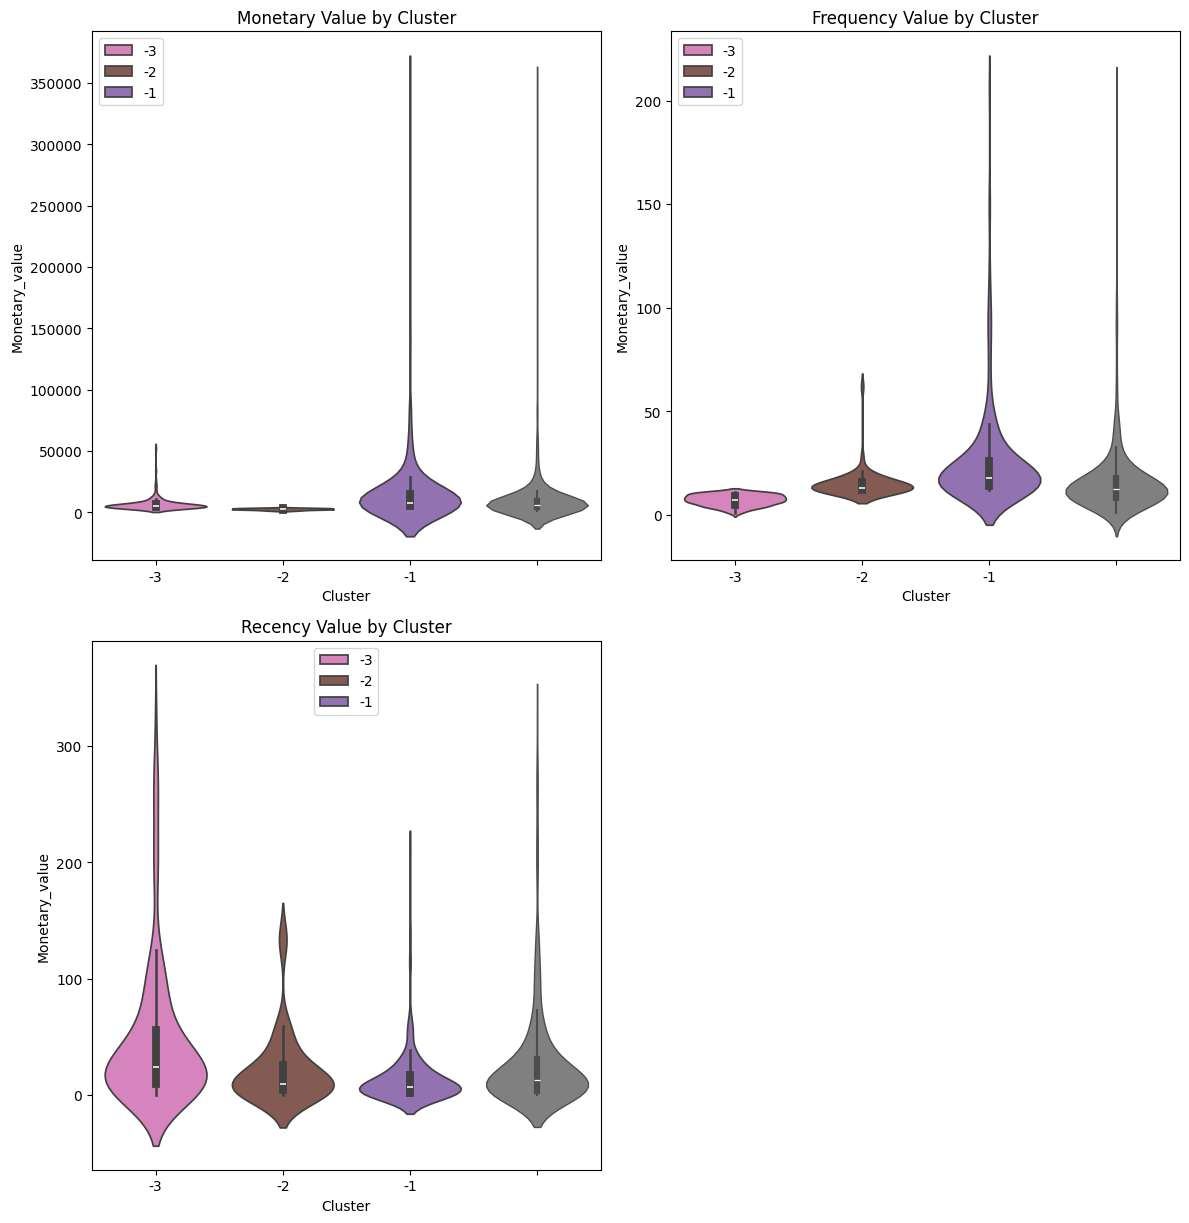

In [79]:
cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'
}

plt.figure(figsize = (12,18))

plt.subplot(3,2,1)
sns.violinplot(x= outliers_cluster_df['Cluster'], y=outliers_cluster_df['MonetaryValue'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y= outliers_cluster_df['MonetaryValue'], color = 'gray',linewidth = 1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary_value')

plt.subplot(3,2,2)
sns.violinplot(x= outliers_cluster_df['Cluster'], y=outliers_cluster_df['Frequency'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y= outliers_cluster_df['Frequency'], color = 'gray',linewidth = 1.0)
plt.title('Frequency Value by Cluster')
plt.ylabel('Monetary_value')

plt.subplot(3,2,3)
sns.violinplot(x= outliers_cluster_df['Cluster'], y=outliers_cluster_df['Recency'], palette = cluster_colors, hue = outliers_cluster_df['Cluster'])
sns.violinplot(y= outliers_cluster_df['Recency'], color = 'gray',linewidth = 1.0)
plt.title('Recency Value by Cluster')
plt.ylabel('Monetary_value')

plt.tight_layout()
plt.show()

In [80]:
cluster_labels = {
    0: 'RE-ENGAGE',
    1: 'NURTURE',
    2: 'REWARD',
    3: 'RETAIN',
    -2: 'UPSELL',
    -3: 'DELIGHT'
}

In [81]:
full_cluster_df = pd.concat([non_outliers_df,outliers_cluster_df])
full_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,372.86,11,2010-06-28 13:53:00,164,3
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,2
2,12348.00,222.16,1,2010-09-27 14:59:00,73,1
3,12349.00,2671.14,3,2010-10-28 08:23:00,42,2
4,12351.00,300.93,1,2010-11-29 15:23:00,10,1
...,...,...,...,...,...,...
4083,17969.00,2141.74,18,2010-07-25 13:08:00,137,-2
4086,17975.00,2540.02,12,2010-12-08 11:38:00,1,-2
4156,18065.00,3473.80,15,2010-11-16 10:05:00,23,-2
4188,18109.00,1840.99,13,2010-12-05 10:58:00,4,-2


In [82]:
full_cluster_df['Cluster_labels'] = full_cluster_df['Cluster'].map(cluster_labels)
full_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,Cluster_labels
0,12346.00,372.86,11,2010-06-28 13:53:00,164,3,RETAIN
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,2,REWARD
2,12348.00,222.16,1,2010-09-27 14:59:00,73,1,NURTURE
3,12349.00,2671.14,3,2010-10-28 08:23:00,42,2,REWARD
4,12351.00,300.93,1,2010-11-29 15:23:00,10,1,NURTURE
...,...,...,...,...,...,...,...
4083,17969.00,2141.74,18,2010-07-25 13:08:00,137,-2,UPSELL
4086,17975.00,2540.02,12,2010-12-08 11:38:00,1,-2,UPSELL
4156,18065.00,3473.80,15,2010-11-16 10:05:00,23,-2,UPSELL
4188,18109.00,1840.99,13,2010-12-05 10:58:00,4,-2,UPSELL


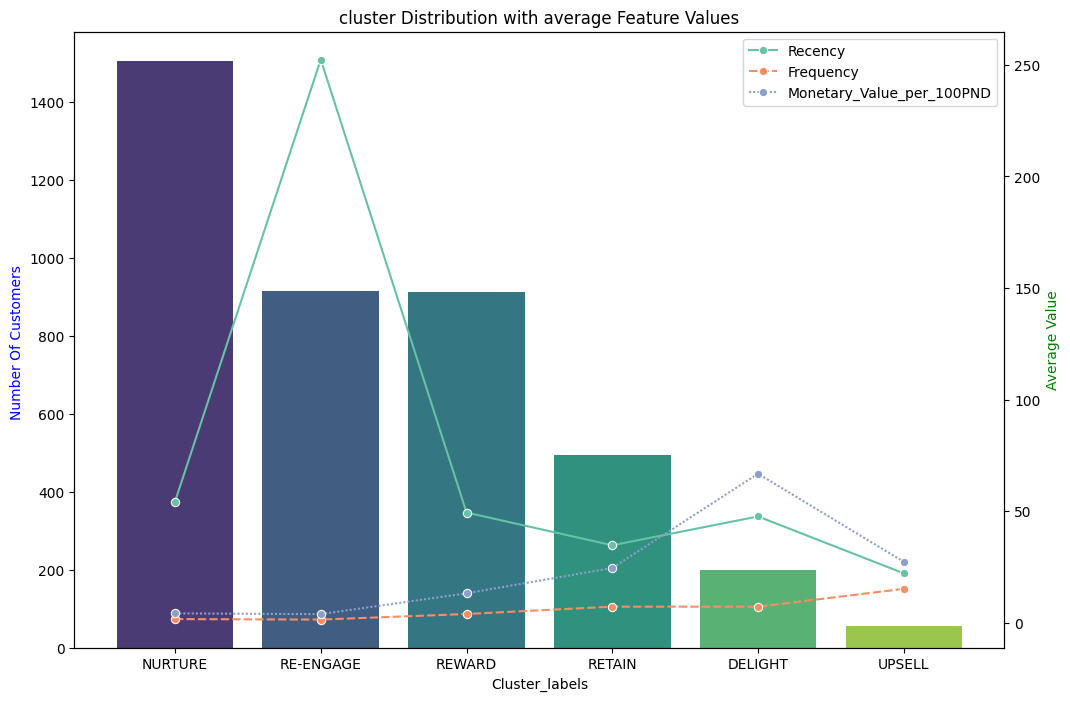

In [83]:
cluster_count = full_cluster_df['Cluster_labels'].value_counts()
full_cluster_df['Monetary_Value_per_100PND'] = full_cluster_df['MonetaryValue'] / 100.00
feature_means =  full_cluster_df.groupby('Cluster_labels')[['Recency','Frequency','Monetary_Value_per_100PND']].mean()

fig,ax1 = plt.subplots(figsize = (12,8))

sns.barplot(x = cluster_count.index,y = cluster_count.values, ax= ax1, palette = 'viridis',hue = cluster_count.index)
ax1.set_ylabel('Number Of Customers ',color = 'b')
ax1.set_title('cluster Distribution with average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data = feature_means, ax = ax2, palette=  'Set2', marker = 'o')
ax2.set_ylabel('Average Value', color = 'g')

plt.show()
